# Импорты и вспомогательные функции

In [1]:
import warnings
warnings.filterwarnings('ignore')

import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from typing import List, Dict
from IPython.display import display, HTML

import umap
from scipy.spatial.distance import cdist
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import DBSCAN, KMeans
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.calibration import CalibratedClassifierCV

from catboost import CatBoostClassifier, CatBoostRegressor
from causalml.inference.tree import UpliftRandomForestClassifier
from sklift.datasets import fetch_x5
from sklift.models import TwoModels
import sklearn.utils
def dummy_check_matplotlib_support(*args, **kwargs):
    pass
sklearn.utils.check_matplotlib_support = dummy_check_matplotlib_support

from sklift.viz import plot_qini_curve, plot_uplift_curve

from sklift.metrics import (
    uplift_auc_score,
    qini_auc_score,
    weighted_average_uplift,
    uplift_at_k,
    uplift_by_percentile
)
from sklift.viz import plot_uplift_by_percentile

# Настройки графиков
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

import os
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))

if parent_dir not in os.sys.path:
    os.sys.path.append(parent_dir)

from extractors.feature_extraction_expanded import *
from extractors.models_extraction import *
from extractors.clusterization_features_extraction import *

In [2]:
# Фиксим вечную проблему sklift-модуля в визуализации графиков

import sklearn.utils
import sklift.viz.base as sklift_viz
import matplotlib.pyplot as plt

# Лечим проверку matplotlib
sklearn.utils.check_matplotlib_support = lambda *args, **kwargs: None

def patched_plot(self, auc_score=None, ax=None, name=None, title='AUC', **kwargs):
    if ax is None:
        _, ax = plt.subplots()

    display_name = name if name else getattr(self, 'estimator_name', None)
    
    label = f"{display_name} (AUC={auc_score:.4f})" if display_name else f"AUC={auc_score:.4f}"
    
    plot_kwargs = {k: v for k, v in kwargs.items() if k not in ['perfect', 'random']}
    
    # Рисуем основную линию
    ax.plot(self.x_actual, self.y_actual, label=label, linewidth=kwargs.get('lw', 2), **plot_kwargs)

    # Рисуем Random линию только один раз на весь график
    handles, labels = ax.get_legend_handles_labels()
    x_base = getattr(self, 'x_baseline', None)
    y_base = getattr(self, 'y_baseline', None)

    if x_base is not None and "Random" not in labels:
        ax.plot(x_base, y_base, label="Random", color="red", linestyle="--", linewidth=1.5, alpha=0.7)
    
    # Подписи осей в зависимости от масштаба
    if self.x_actual[-1] <= 1.1:
        ax.set_xlabel("Percent of population targeted")
        ax.set_ylabel("Incremental Outcome (Qini)")
    else:
        ax.set_xlabel("Number targeted")
        ax.set_ylabel("Cumulative Uplift")
    
    return self

# Перезаписываем метод
sklift_viz.UpliftCurveDisplay.plot = patched_plot

In [3]:
# У реализации sklift не получается связка с текущей версией numpy, которую мы поставили для работы causalml на UpliftTree, поэтому напишем собственные графики

def get_uplift_percentile_table(y_true, uplift_preds, treatment, bins=10):
    y_true = np.asarray(y_true).reshape(-1)
    uplift_preds = np.asarray(uplift_preds).reshape(-1)
    treatment = np.asarray(treatment).reshape(-1)

    df = uplift_by_percentile(
        y_true=y_true,
        uplift=uplift_preds,
        treatment=treatment,
        strategy='overall',
        bins=bins,
        std=False,
        total=False,
        string_percentiles=True
    ).reset_index()

    if 'index' in df.columns:
        df = df.rename(columns={'index': 'percentile'})

    # На всякий случай приводим к числам
    numeric_cols = [
        'n_treatment',
        'n_control',
        'response_rate_treatment',
        'response_rate_control',
        'uplift'
    ]
    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    # Стандартные ошибки для error bars
    p_t = df['response_rate_treatment'].to_numpy()
    p_c = df['response_rate_control'].to_numpy()
    n_t = df['n_treatment'].to_numpy()
    n_c = df['n_control'].to_numpy()

    se_t = np.sqrt(np.where(n_t > 0, p_t * (1 - p_t) / n_t, np.nan))
    se_c = np.sqrt(np.where(n_c > 0, p_c * (1 - p_c) / n_c, np.nan))
    se_u = np.sqrt(np.nan_to_num(se_t, nan=0.0) ** 2 + np.nan_to_num(se_c, nan=0.0) ** 2)

    df['se_treatment'] = se_t
    df['se_control'] = se_c
    df['se_uplift'] = se_u

    return df

def plot_percentile_grid(preds_dict, y_true, treatment, split_name, bins=10):
    model_names = list(preds_dict.keys())

    fig = plt.figure(figsize=(18, 14))
    outer = fig.add_gridspec(2, 2, wspace=0.22, hspace=0.28)

    for i, model_name in enumerate(model_names):
        row, col = divmod(i, 2)

        inner = outer[row, col].subgridspec(
            2, 1,
            height_ratios=[1, 1.05],
            hspace=0.18
        )

        ax_top = fig.add_subplot(inner[0])
        ax_bottom = fig.add_subplot(inner[1], sharex=ax_top)

        preds = preds_dict[model_name]
        df = get_uplift_percentile_table(
            y_true=y_true,
            uplift_preds=preds,
            treatment=treatment,
            bins=bins
        )

        wau = weighted_average_uplift(y_true, preds, treatment)

        x = np.arange(len(df))
        width = 0.36

        # Верхний график: uplift by percentile
        ax_top.bar(
            x,
            df['uplift'],
            yerr=df['se_uplift'],
            capsize=2,
            color='red',
            alpha=0.95,
            edgecolor='black',
            linewidth=0.3,
            label='uplift'
        )
        ax_top.axhline(0, color='black', linewidth=1)

        ax_top.set_title(
            f'{model_name}\nUplift by percentile\nweighted average uplift = {wau:.4f}',
            fontsize=11,
            fontweight='bold'
        )
        ax_top.set_ylabel('Uplift = treatment response rate - control response rate', fontsize=10)
        ax_top.legend(loc='upper right', fontsize=9, frameon=True)
        ax_top.grid(axis='y', linestyle='--', alpha=0.35)
        ax_top.tick_params(axis='x', labelbottom=False)

        # Нижний график: response rate by percentile
        ax_bottom.bar(
            x - width / 2,
            df['response_rate_treatment'],
            width=width,
            yerr=df['se_treatment'],
            capsize=2,
            color='forestgreen',
            alpha=0.95,
            edgecolor='black',
            linewidth=0.3,
            label='treatment\nresponse rate'
        )

        ax_bottom.bar(
            x + width / 2,
            df['response_rate_control'],
            width=width,
            yerr=df['se_control'],
            capsize=2,
            color='orange',
            alpha=0.95,
            edgecolor='black',
            linewidth=0.3,
            label='control\nresponse rate'
        )

        ax_bottom.set_title('Response rate by percentile', fontsize=11, fontweight='bold')
        ax_bottom.set_ylabel('response rate', fontsize=10)
        ax_bottom.set_xlabel('Percentile', fontsize=10)
        ax_bottom.set_xticks(x)
        ax_bottom.set_xticklabels(df['percentile'], rotation=35)
        ax_bottom.legend(loc='upper right', fontsize=9, frameon=True)
        ax_bottom.grid(axis='y', linestyle='--', alpha=0.35)

    fig.suptitle(f'Uplift by percentile | {split_name}', fontsize=16, fontweight='bold', y=0.995)
    plt.tight_layout(rect=[0, 0, 1, 0.985])
    plt.show()

In [4]:
def calculate_metrics(y_true, uplift_preds, treatment):
    return {
        "AUUC": uplift_auc_score(y_true, uplift_preds, treatment),
        "Qini": qini_auc_score(y_true, uplift_preds, treatment),
        "WAU": weighted_average_uplift(y_true, uplift_preds, treatment),
        "Uplift@10%": uplift_at_k(y_true, uplift_preds, treatment, strategy='overall', k=0.1),
        "Uplift@20%": uplift_at_k(y_true, uplift_preds, treatment, strategy='overall', k=0.2),
        "Uplift@30%": uplift_at_k(y_true, uplift_preds, treatment, strategy='overall', k=0.3),
        "Uplift@50%": uplift_at_k(y_true, uplift_preds, treatment, strategy='overall', k=0.5)
    }

# Подготовка датасета

In [5]:
dataset = fetch_x5()
data = dataset.data

In [6]:
extractor = UpliftFeatureExtractorExpanded(drop_redundant=True)
df = extractor.calculate_features(
    clients_df=data.clients,
    train_df=data.train,
    treatment_df=dataset.treatment,
    target_df=dataset.target,
    purchases_df=data.purchases
)

del data, dataset
gc.collect()

features = extractor.feature_names
TARGET_COL = "target"
TREATMENT_COL = "treatment_flg"

X_all = df[features].copy()
y_all = df[TARGET_COL].values
t_all = df[TREATMENT_COL].values

print(f"Размер итогового датасета: {X_all.shape}")

Размер итогового датасета: (200039, 45)


In [7]:
strata_all = pd.Series(t_all).astype(str) + '_' + pd.Series(y_all).astype(str)

x_train_full, x_test_holdout, y_train_full, y_test_holdout, t_train_full, t_test_holdout = train_test_split(
    X_all,
    y_all,
    t_all,
    test_size=0.2,
    random_state=42,
    stratify=strata_all
)

print(x_train_full.shape, x_test_holdout.shape)

(160031, 45) (40008, 45)


In [8]:
current_num_cols = x_train_full.select_dtypes(include=['number']).columns.tolist()
clusterizer_full = UmapClusterTransformer(num_cols=current_num_cols, n_clusters=5)

x_train_full_clust = clusterizer_full.fit_transform(x_train_full)
x_test_holdout_clust = clusterizer_full.transform(x_test_holdout)

cat_cols_full = x_train_full_clust.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols_full = x_train_full_clust.select_dtypes(include=['number']).columns.tolist()

# Модели для сравнения

In [9]:
test_holdout_preds = {}
test_results_list = []

In [10]:
# t-learner (для сравнения)
t_learner_full = build_t_learner_logreg(num_cols_full, cat_cols_full)
t_learner_full.estimator_trmnt = CalibratedClassifierCV(t_learner_full.estimator_trmnt, method='isotonic', cv=3)
t_learner_full.estimator_ctrl = CalibratedClassifierCV(t_learner_full.estimator_ctrl, method='isotonic', cv=3)

t_learner_full.fit(x_train_full_clust, y_train_full, t_train_full)
preds_t_test = t_learner_full.predict(x_test_holdout_clust)

test_holdout_preds['T-Learner (LogReg)'] = preds_t_test
test_results_list.append({
    'Model': 'T-Learner (LogReg)',
    'Split': 'test_holdout',
    **calculate_metrics(y_test_holdout, preds_t_test, t_test_holdout)
})

In [11]:
# x-learner (для сравнения)
x_learner_full = build_x_learner_catboost(cat_features=cat_cols_full, use_calibration=True)
x_learner_full.outcome_learner = CalibratedClassifierCV(x_learner_full.outcome_learner, method='isotonic', cv=3)
x_learner_full.propensity_learner = CalibratedClassifierCV(x_learner_full.propensity_learner, method='isotonic', cv=3)

x_learner_full.fit(x_train_full_clust, y_train_full, t_train_full)
preds_x_test = x_learner_full.predict(x_test_holdout_clust)

test_holdout_preds['X-Learner (CatBoost)'] = preds_x_test
test_results_list.append({
    'Model': 'X-Learner (CatBoost)',
    'Split': 'test_holdout',
    **calculate_metrics(y_test_holdout, preds_x_test, t_test_holdout)
})

0:	learn: 0.6836937	total: 202ms	remaining: 29.5s
100:	learn: 0.5576336	total: 4.86s	remaining: 2.21s
146:	learn: 0.5552556	total: 7.02s	remaining: 0us
0:	learn: 0.6838014	total: 42.8ms	remaining: 6.24s
100:	learn: 0.5587178	total: 4.68s	remaining: 2.13s
146:	learn: 0.5562381	total: 6.81s	remaining: 0us
0:	learn: 0.6836975	total: 43.4ms	remaining: 6.34s
100:	learn: 0.5576685	total: 4.71s	remaining: 2.15s
146:	learn: 0.5550320	total: 6.87s	remaining: 0us
0:	learn: 0.6833008	total: 45.6ms	remaining: 6.66s
100:	learn: 0.5492651	total: 4.67s	remaining: 2.13s
146:	learn: 0.5462719	total: 6.82s	remaining: 0us
0:	learn: 0.6826693	total: 43.9ms	remaining: 6.41s
100:	learn: 0.5458391	total: 4.71s	remaining: 2.15s
146:	learn: 0.5427726	total: 6.88s	remaining: 0us
0:	learn: 0.6832889	total: 49.5ms	remaining: 7.23s
100:	learn: 0.5479622	total: 4.73s	remaining: 2.15s
146:	learn: 0.5450608	total: 6.88s	remaining: 0us
0:	learn: 0.4362878	total: 27.6ms	remaining: 4.03s
100:	learn: 0.4346261	total: 2.9

# Новая модель (TARNet)

In [12]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.preprocessing import LabelEncoder, StandardScaler

class TabularDataset(Dataset):
    def __init__(self, x_num, x_cat, y=None, t=None):
        self.x_num = torch.tensor(x_num, dtype=torch.float32)
        self.x_cat = torch.tensor(x_cat, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.float32) if y is not None else None
        self.t = torch.tensor(t, dtype=torch.float32) if t is not None else None

    def __len__(self):
        return len(self.x_num)

    def __getitem__(self, idx):
        item = {'x_num': self.x_num[idx], 'x_cat': self.x_cat[idx]}
        if self.y is not None:
            item['y'] = self.y[idx]
        if self.t is not None:
            item['t'] = self.t[idx]
        return item

class ClassicTARNet(nn.Module):
    def __init__(self, n_num_features, cardinalities, cat_emb_dim=8, 
                 shared_hidden=[256, 128], head_hidden=[64, 32], 
                 dropout=0.2):
        super().__init__()
        
        self.embeddings = nn.ModuleList([
            nn.Embedding(card + 1, cat_emb_dim) for card in cardinalities
        ])
        
        input_dim = n_num_features + len(cardinalities) * cat_emb_dim
        
        shared_layers =[]
        prev_dim = input_dim
        for h_dim in shared_hidden:
            shared_layers.append(nn.Linear(prev_dim, h_dim))
            shared_layers.append(nn.BatchNorm1d(h_dim))
            shared_layers.append(nn.Mish())
            shared_layers.append(nn.Dropout(dropout))
            prev_dim = h_dim
        self.shared_representation = nn.Sequential(*shared_layers)
        
        treat_layers =[]
        t_prev = prev_dim
        for h_dim in head_hidden:
            treat_layers.append(nn.Linear(t_prev, h_dim))
            treat_layers.append(nn.BatchNorm1d(h_dim))
            treat_layers.append(nn.Mish())
            treat_layers.append(nn.Dropout(dropout))
            t_prev = h_dim
        treat_layers.append(nn.Linear(t_prev, 1))
        self.treatment_head = nn.Sequential(*treat_layers)
        
        ctrl_layers =[]
        c_prev = prev_dim
        for h_dim in head_hidden:
            ctrl_layers.append(nn.Linear(c_prev, h_dim))
            ctrl_layers.append(nn.BatchNorm1d(h_dim))
            ctrl_layers.append(nn.Mish())
            ctrl_layers.append(nn.Dropout(dropout))
            c_prev = h_dim
        ctrl_layers.append(nn.Linear(c_prev, 1))
        self.control_head = nn.Sequential(*ctrl_layers)

    def forward(self, x_num, x_cat):
        # Объединяем числа и эмбеддинги
        if x_cat.size(1) > 0:
            cat_embs = [emb(x_cat[:, i]) for i, emb in enumerate(self.embeddings)]
            x_cat_emb = torch.cat(cat_embs, dim=1)
            x = torch.cat([x_num, x_cat_emb], dim=1)
        else:
            x = x_num
            
        rep = self.shared_representation(x)
        
        p_treatment = torch.sigmoid(self.treatment_head(rep)).squeeze(-1)
        p_control = torch.sigmoid(self.control_head(rep)).squeeze(-1)
        
        return p_treatment, p_control

class ClassicTARNetUpliftClassifier(BaseEstimator, ClassifierMixin):
    def __init__(
        self, num_cols, cat_cols, shared_hidden=[256, 128], head_hidden=[64, 32],
        cat_emb_dim=8, dropout=0.2, lr=1e-3, n_epochs=30, batch_size=512, device=None
    ):
        self.num_cols = num_cols
        self.cat_cols = cat_cols
        self.shared_hidden = shared_hidden
        self.head_hidden = head_hidden
        self.cat_emb_dim = cat_emb_dim
        self.dropout = dropout
        self.lr = lr
        self.n_epochs = n_epochs
        self.batch_size = batch_size
        self.device = device or ('cuda' if torch.cuda.is_available() else 'cpu')
        print(f"Device: {self.device}")

    def _prepare_data(self, X):
        X = pd.DataFrame(X) if not isinstance(X, pd.DataFrame) else X.copy()
        x_num = X[self.num_cols].fillna(0).values.astype(np.float32)
        x_cat = np.zeros((len(X), len(self.cat_cols)), dtype=np.int64)
        for i, col in enumerate(self.cat_cols):
            le = self.label_encoders_[col]
            vals = X[col].astype(str).values
            x_cat[:, i] = np.array([
                le.transform([v])[0] if v in le.classes_ else len(le.classes_)
                for v in vals
            ])
        return x_num, x_cat

    def fit(self, X, y, t):
        X = pd.DataFrame(X) if not isinstance(X, pd.DataFrame) else X.copy()
        
        self.label_encoders_ = {}
        for col in self.cat_cols:
            le = LabelEncoder()
            le.fit(X[col].astype(str).values)
            self.label_encoders_[col] = le
            
        cardinalities = [len(self.label_encoders_[col].classes_) for col in self.cat_cols]

        self.scaler_ = StandardScaler()
        X[self.num_cols] = self.scaler_.fit_transform(X[self.num_cols].fillna(0))

        x_num, x_cat = self._prepare_data(X)

        self.model_ = ClassicTARNet(
            n_num_features=len(self.num_cols),
            cardinalities=cardinalities,
            cat_emb_dim=self.cat_emb_dim,
            shared_hidden=self.shared_hidden,
            head_hidden=self.head_hidden,
            dropout=self.dropout
        ).to(self.device)

        optimizer = torch.optim.AdamW(self.model_.parameters(), lr=self.lr, weight_decay=1e-4)
        dataset = TabularDataset(x_num, x_cat, y, t)
        loader = DataLoader(dataset, batch_size=self.batch_size, shuffle=True, pin_memory=True)

        self.model_.train()
        for epoch in range(self.n_epochs):
            total_loss = 0
            for batch in loader:
                x_n = batch['x_num'].to(self.device)
                x_c = batch['x_cat'].to(self.device)
                y_b = batch['y'].to(self.device)
                t_b = batch['t'].to(self.device)

                p_t, p_c = self.model_(x_n, x_c)

                loss_t = F.binary_cross_entropy(p_t[t_b == 1], y_b[t_b == 1]) if (t_b == 1).any() else 0
                loss_c = F.binary_cross_entropy(p_c[t_b == 0], y_b[t_b == 0]) if (t_b == 0).any() else 0
                loss = loss_t + loss_c

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                total_loss += loss.item()

            print(f"Epoch {epoch+1}/{self.n_epochs} | Loss: {total_loss/len(loader):.4f}")

        return self

    def predict(self, X):
        X = pd.DataFrame(X) if not isinstance(X, pd.DataFrame) else X.copy()
        X[self.num_cols] = self.scaler_.transform(X[self.num_cols].fillna(0))
        x_num, x_cat = self._prepare_data(X)

        dataset = TabularDataset(x_num, x_cat)
        loader = DataLoader(dataset, batch_size=self.batch_size, shuffle=False)

        self.model_.eval()
        p_ts, p_cs = [],[]
        with torch.no_grad():
            for batch in loader:
                x_n = batch['x_num'].to(self.device)
                x_c = batch['x_cat'].to(self.device)
                p_t, p_c = self.model_(x_n, x_c)
                p_ts.append(p_t.cpu().numpy())
                p_cs.append(p_c.cpu().numpy())

        p_t_all = np.concatenate(p_ts)
        p_c_all = np.concatenate(p_cs)
        
        return p_t_all - p_c_all

In [13]:
tarnet_classic = ClassicTARNetUpliftClassifier(
    num_cols=num_cols_full,
    cat_cols=cat_cols_full,
    shared_hidden=[128, 64],
    head_hidden=[32, 16],
    dropout=0.2,
    lr=1e-3,
    n_epochs=40,
    batch_size=512
)

tarnet_classic.fit(x_train_full_clust, y_train_full, t_train_full)

preds_tarnet_classic_test = tarnet_classic.predict(x_test_holdout_clust)

test_holdout_preds['TARNet (Classic MLP)'] = preds_tarnet_classic_test
test_results_list.append({
    'Model': 'TARNet (Classic MLP)',
    'Split': 'test_holdout',
    **calculate_metrics(y_test_holdout, preds_tarnet_classic_test, t_test_holdout)
})

Device: cuda
Epoch 1/40 | Loss: 1.1442
Epoch 2/40 | Loss: 1.1218
Epoch 3/40 | Loss: 1.1189
Epoch 4/40 | Loss: 1.1170
Epoch 5/40 | Loss: 1.1157
Epoch 6/40 | Loss: 1.1147
Epoch 7/40 | Loss: 1.1134
Epoch 8/40 | Loss: 1.1133
Epoch 9/40 | Loss: 1.1120
Epoch 10/40 | Loss: 1.1108
Epoch 11/40 | Loss: 1.1106
Epoch 12/40 | Loss: 1.1091
Epoch 13/40 | Loss: 1.1098
Epoch 14/40 | Loss: 1.1097
Epoch 15/40 | Loss: 1.1082
Epoch 16/40 | Loss: 1.1081
Epoch 17/40 | Loss: 1.1073
Epoch 18/40 | Loss: 1.1075
Epoch 19/40 | Loss: 1.1070
Epoch 20/40 | Loss: 1.1066
Epoch 21/40 | Loss: 1.1057
Epoch 22/40 | Loss: 1.1058
Epoch 23/40 | Loss: 1.1053
Epoch 24/40 | Loss: 1.1047
Epoch 25/40 | Loss: 1.1051
Epoch 26/40 | Loss: 1.1043
Epoch 27/40 | Loss: 1.1037
Epoch 28/40 | Loss: 1.1045
Epoch 29/40 | Loss: 1.1024
Epoch 30/40 | Loss: 1.1029
Epoch 31/40 | Loss: 1.1028
Epoch 32/40 | Loss: 1.1023
Epoch 33/40 | Loss: 1.1026
Epoch 34/40 | Loss: 1.1028
Epoch 35/40 | Loss: 1.1023
Epoch 36/40 | Loss: 1.1020
Epoch 37/40 | Loss: 1.10

# Метрики

In [14]:
test_results_df = pd.DataFrame(test_results_list)
display(test_results_df)

,Model,Split,AUUC,Qini,WAU,Uplift@10%,Uplift@20%,Uplift@30%,Uplift@50%
0,T-Learner (LogReg),test_holdout,0.020937,0.013533,0.033329,0.108997,0.084910,0.067048,0.048434
1,X-Learner (CatBoost),test_holdout,0.022241,0.014585,0.034241,0.110987,0.079301,0.063015,0.046522
2,TARNet (Classic MLP),test_holdout,0.017937,0.011763,0.033585,0.108619,0.075113,0.056091,0.048088


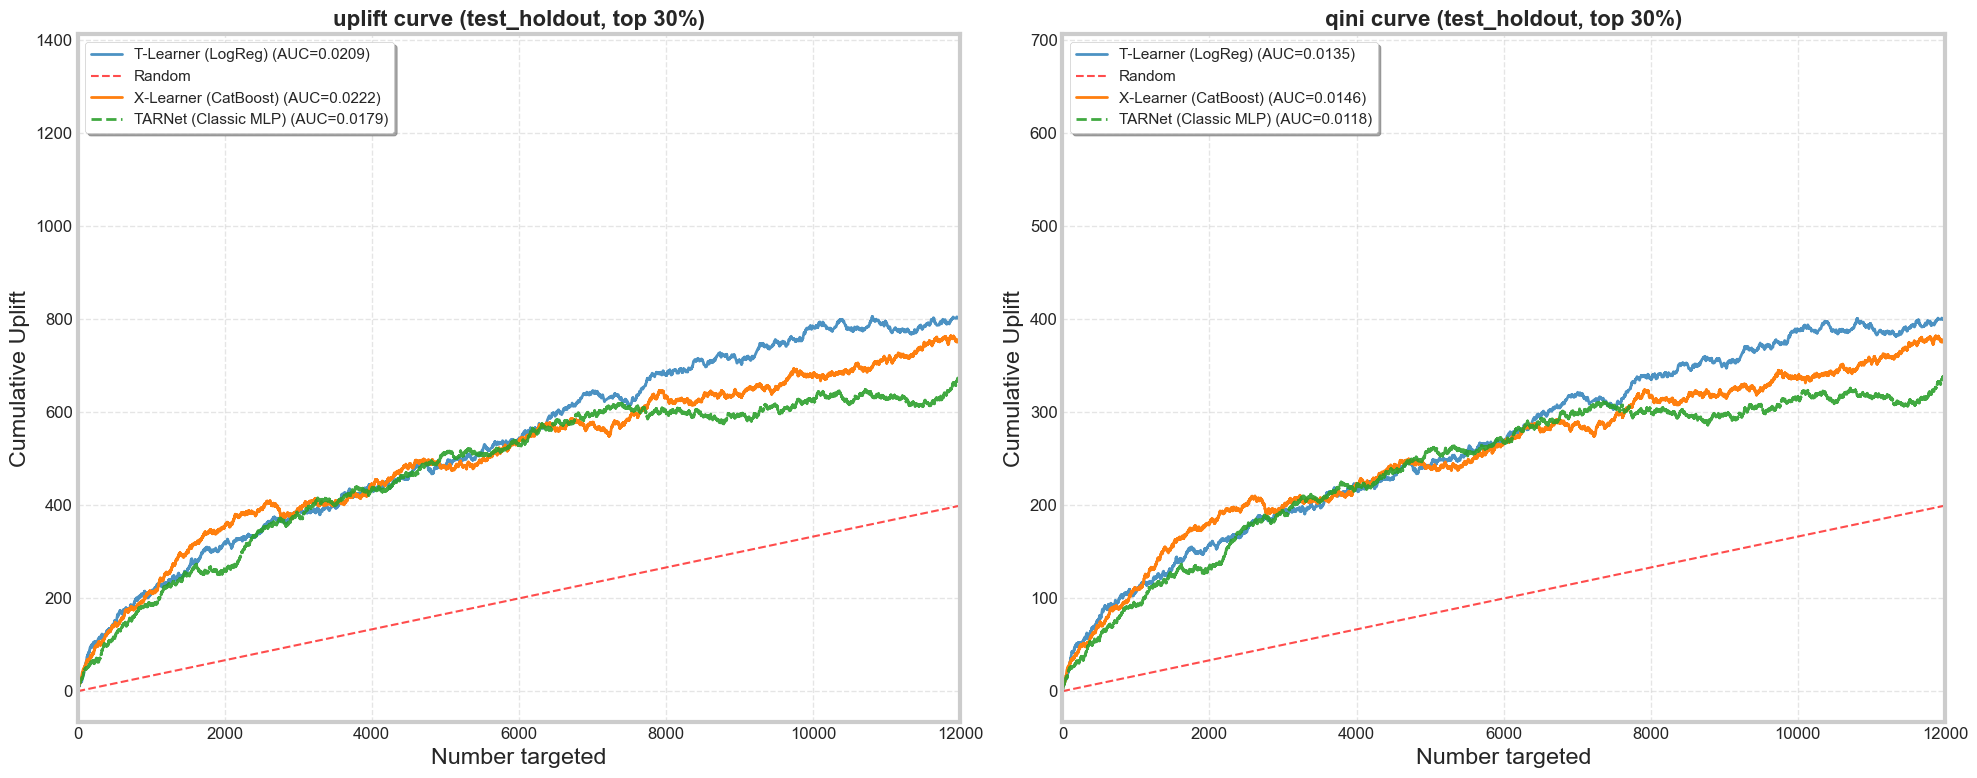

In [15]:
top_k_percent = 0.3

model_colors = {
    "T-Learner (LogReg)": "#1f77b4",
    "TARNet (Classic MLP)": "#2ca02c",
    "X-Learner (CatBoost)": "#ff7f0e"
}

model_styles = {
    "T-Learner (LogReg)": {"ls": "-", "alpha": 0.8},
    "TARNet (Classic MLP)": {"ls": "--", "alpha": 0.9},
    "X-Learner (CatBoost)": {"ls": "-", "alpha": 1.0}
}

split_specs = {
    "test_holdout": {
        "y": y_test_holdout,
        "t": t_test_holdout,
        "preds_dict": test_holdout_preds
    }
}

for split_name, split_data in split_specs.items():
    y_split = split_data["y"]
    t_split = split_data["t"]
    preds_dict = split_data["preds_dict"]

    max_x = int(len(y_split) * top_k_percent)

    fig, axes = plt.subplots(1, 2, figsize=(20, 8))

    for model_name, preds in preds_dict.items():
        style = model_styles.get(model_name, {"ls": "-", "alpha": 0.8})
        color = model_colors.get(model_name, "gray")

        plot_uplift_curve(
            y_split,
            preds,
            t_split,
            name=model_name,
            ax=axes[0],
            color=color,
            perfect=False,
            **style
        )

        plot_qini_curve(
            y_split,
            preds,
            t_split,
            name=model_name,
            ax=axes[1],
            color=color,
            perfect=False,
            **style
        )

    axes[0].set_title(f"uplift curve ({split_name}, top 30%)", fontsize=16, fontweight='bold')
    axes[1].set_title(f"qini curve ({split_name}, top 30%)", fontsize=16, fontweight='bold')

    for ax in axes:
        ax.set_xlim(0, max_x)
        ax.legend(loc='upper left', fontsize=11, frameon=True, shadow=True)
        ax.grid(True, which='both', linestyle='--', alpha=0.5)
        ax.tick_params(axis='both', which='major', labelsize=12)

    plt.tight_layout()
    plt.show()

In [16]:
percentile_frames = []

for model_name, preds in test_holdout_preds.items():
    df_test_pct = uplift_by_percentile(
        y_true=y_test_holdout,
        uplift=preds,
        treatment=t_test_holdout,
        strategy='overall',
        bins=10,
        std=False,
        total=False,
        string_percentiles=True
    ).reset_index().rename(columns={'index': 'percentile'})

    df_test_pct['Model'] = model_name
    df_test_pct['Split'] = 'test_holdout'
    percentile_frames.append(df_test_pct)

all_percentiles_df = pd.concat(percentile_frames, ignore_index=True)

for col in ['n_treatment', 'n_control']:
    all_percentiles_df[col] = all_percentiles_df[col].round().astype('Int64')

all_percentiles_df['n_total'] = all_percentiles_df['n_treatment'] + all_percentiles_df['n_control']

In [17]:
split_name = 'test_holdout'

split_percentiles_df = all_percentiles_df[all_percentiles_df['Split'] == split_name].copy()

pivot_uplift = split_percentiles_df.pivot(index='percentile', columns='Model', values='uplift').reset_index()
pivot_n_treat = split_percentiles_df.pivot(index='percentile', columns='Model', values='n_treatment').reset_index()
pivot_n_ctrl = split_percentiles_df.pivot(index='percentile', columns='Model', values='n_control').reset_index()
pivot_n_total = split_percentiles_df.pivot(index='percentile', columns='Model', values='n_total').reset_index()

display_df = pivot_uplift.copy()
display_df = display_df.rename(columns={'percentile': 'Перцентиль (бакет)'})
model_columns = [col for col in display_df.columns if col != 'Перцентиль (бакет)']

for model in model_columns:
    display_df[model] = (
        pivot_uplift[model].apply(lambda x: f'{x:+.2%}' if pd.notna(x) else 'nan')
        + '\n' +
        'n=' + pivot_n_total[model].apply(lambda x: f'{int(x)}' if pd.notna(x) else 'nan')
        + ', t=' + pivot_n_treat[model].apply(lambda x: f'{int(x)}' if pd.notna(x) else 'nan')
        + ', c=' + pivot_n_ctrl[model].apply(lambda x: f'{int(x)}' if pd.notna(x) else 'nan')
    )

gmap_df = pivot_uplift[model_columns].copy()
gmap_df.index = display_df.index

styled_df = (
    display_df.style
    .background_gradient(
        cmap='RdYlGn',
        subset=model_columns,
        gmap=gmap_df,
        vmin=-0.05,
        vmax=0.05,
        axis=None
    )
    .set_properties(**{
        'text-align': 'center',
        'border': '1px solid black',
        'white-space': 'pre-line'
    })
    .set_table_styles([
        {
            'selector': 'th',
            'props': [
                ('text-align', 'center'),
                ('background-color', '#ff7f0e'),
                ('border', '1px solid black')
            ]
        }
    ])
    .hide(axis='index')
)

display(styled_df)

Перцентиль (бакет),T-Learner (LogReg),TARNet (Classic MLP),X-Learner (CatBoost)
0-10,"+10.87% n=4001, t=1998, c=2003","+10.88% n=4001, t=2032, c=1969","+11.12% n=4001, t=2004, c=1997"
10-20,"+6.23% n=4001, t=1953, c=2048","+4.14% n=4001, t=1972, c=2029","+4.72% n=4001, t=2003, c=1998"
20-30,"+3.03% n=4001, t=2029, c=1972","+1.83% n=4001, t=2021, c=1980","+3.11% n=4001, t=1991, c=2010"
30-40,"+0.99% n=4001, t=2020, c=1981","+3.65% n=4001, t=1981, c=2020","+2.03% n=4001, t=2034, c=1967"
40-50,"+2.74% n=4001, t=2040, c=1961","+3.56% n=4001, t=2016, c=1985","+2.06% n=4001, t=2029, c=1972"
50-60,"+0.26% n=4001, t=1977, c=2024","-0.04% n=4001, t=2023, c=1978","+3.30% n=4001, t=2047, c=1954"
60-70,"+1.28% n=4001, t=2010, c=1991","+3.27% n=4001, t=2030, c=1971","+4.25% n=4001, t=1955, c=2046"
70-80,"+3.61% n=4001, t=1992, c=2009","+2.18% n=4001, t=1963, c=2038","+0.26% n=4001, t=1991, c=2010"
80-90,"+2.24% n=4000, t=1977, c=2023","+1.80% n=4000, t=2000, c=2000","+1.30% n=4000, t=2002, c=1998"
90-100,"+2.15% n=4000, t=2000, c=2000","+2.20% n=4000, t=1958, c=2042","+2.10% n=4000, t=1940, c=2060"


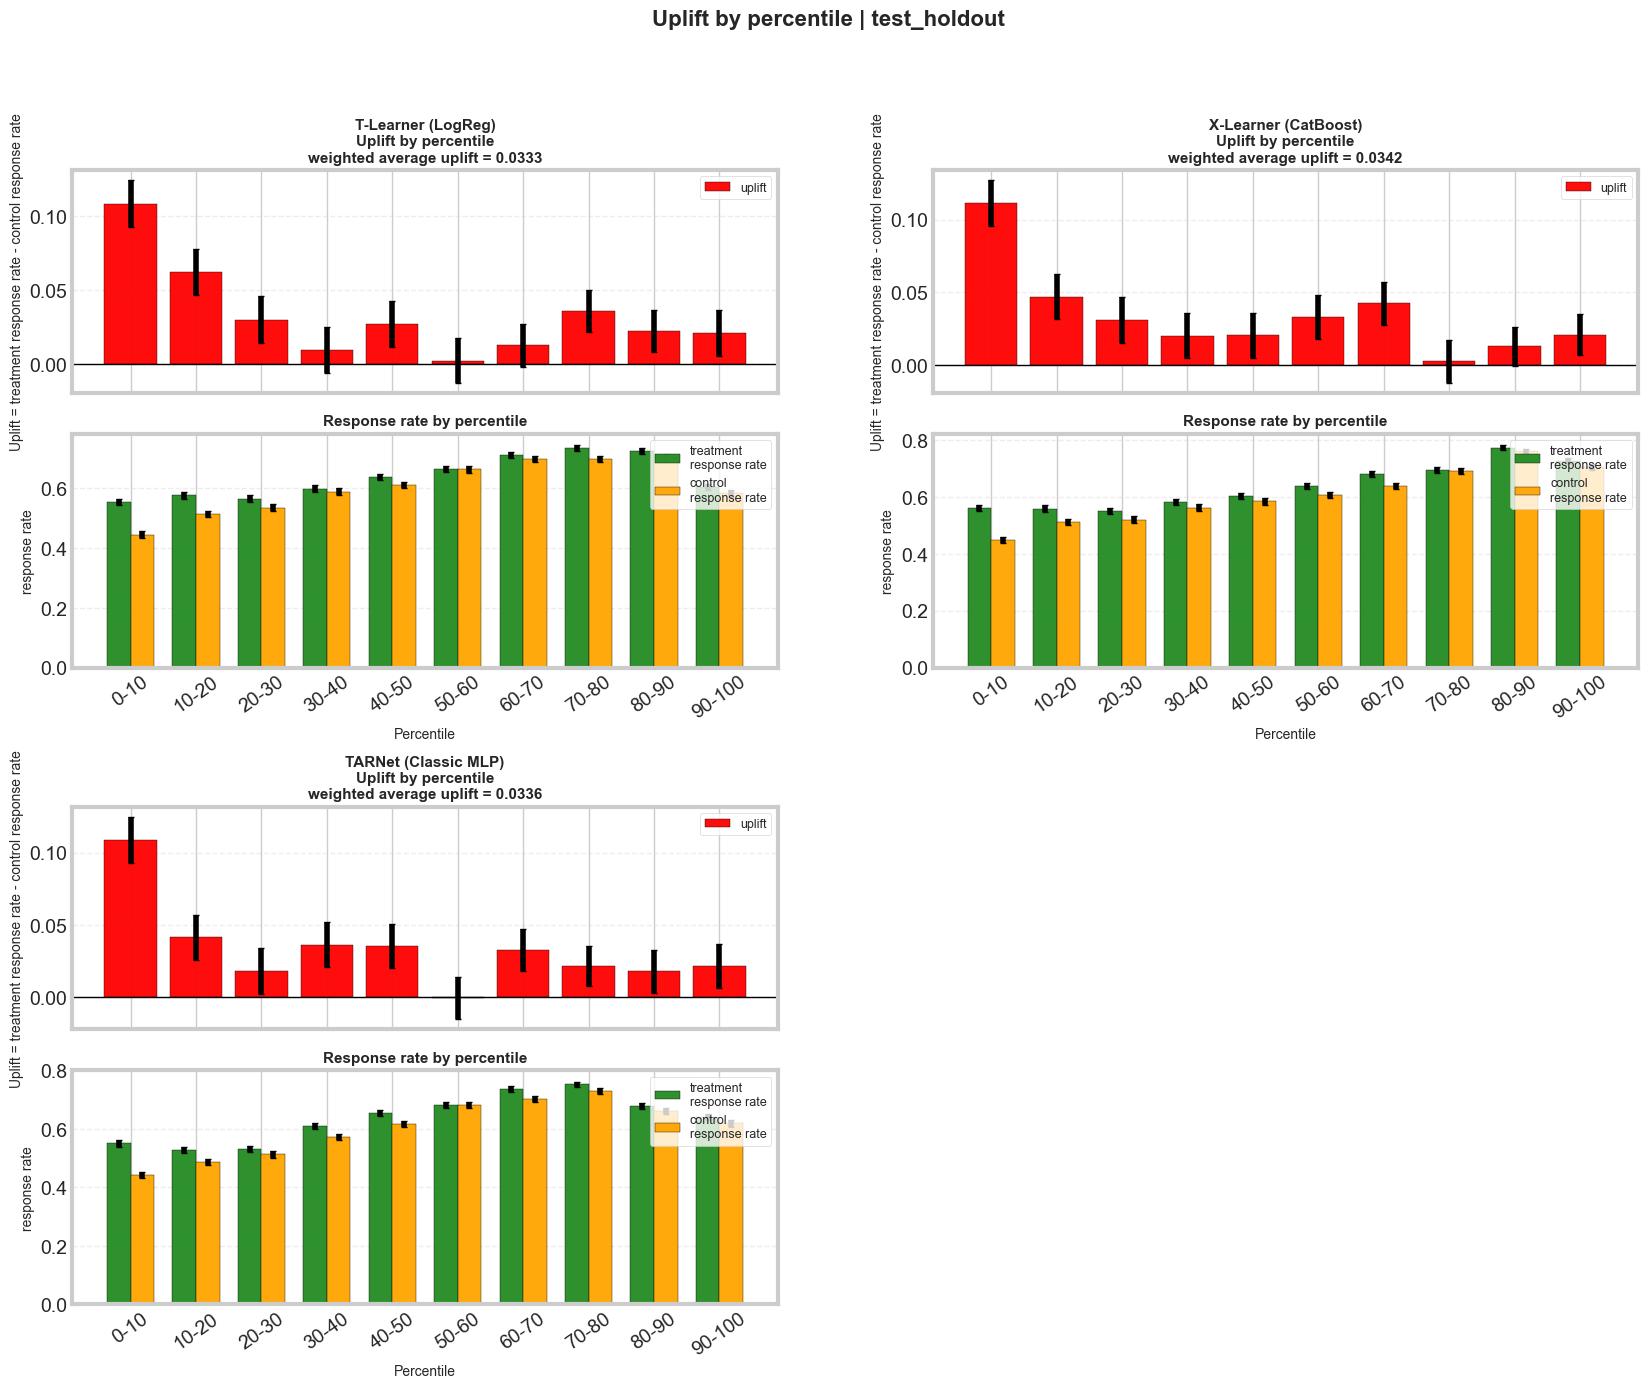

In [18]:
plot_percentile_grid(
    preds_dict=test_holdout_preds,
    y_true=y_test_holdout,
    treatment=t_test_holdout,
    split_name='test_holdout',
    bins=10
)

# Вывод

TARNet на табличных данных ожидаемо показал результаты уступающие бустингу.